# Cosmic-ray transport equation solver
## **Spatial diffusion**

#### Imports

In [1]:
include("../Code/CRT_func_3D.jl");
include("../Code/CRT_tools_3D.jl");

#### Constants

In [2]:
const pc = 3e18;
const kpc = 1e3 * pc;

#### Grid definition

In [3]:
nr, nz, np = 40, 41, 10;

r_min, r_max = pc, kpc;
z_min, z_max = pc, kpc;
p_min, p_max = 1.0, 1e6;

r_list, z_list, p_list, pu_list = make_grids(nr, nz, np, r_min, r_max, z_min, z_max, p_min, p_max);

#### Physical parameters

In [4]:
D_0 = 1e28;
f = 0.1;
R = r_list[end];
L = z_list[end];

#### Functions for diffusion coefficients and absence of wind (no advection)

In [5]:
Dr(r, z, p) = D_0 * (1 + r^2 / R^2);
Dz(r, z, p) = f * D_0;
no_wind(z) = 0.0;

#### Analytical solution for radial-axial diffusion

In [6]:
function N_diff(r::Float64, z::Float64, p::Float64)
    return cos((pi * r) / (2 * R)) * cos((pi * z) / (2 * L))
end

N_sol_diff = zeros(nr, nz)

for j in eachindex(z_list)
    for i in eachindex(r_list)
        N_sol_diff[i, j] = N_diff(r_list[i], z_list[j], p_list[1])
    end
end

#### Source term 

In [7]:
function Q_diff(r::Float64, z::Float64, p::Float64)
    term_1 = (Dr(r, z, p) / R^2) + (Dz(r, z, p) / L^2)
    term_1 *= pi^2 * N_diff(r, z, p) / 4
    term_2 = ((pi * D_0) / (2 * R^2)) * ((R / r) + (3 * r / R))
    term_2 *= sin((pi * r) / (2 * R)) * cos((pi * z) / (2 * L))
    return term_1 + term_2
end


Q_arr_diff = zeros(nr, nz, np)

for k in eachindex(p_list)
    for j in eachindex(z_list)
        for i in eachindex(r_list)
            Q_arr_diff[i, j, k] = Q_diff(r_list[i], z_list[j], p_list[k])
        end
    end
end

#### Time step definition

In [8]:
m = 10;
Dt_list = make_dt_list(1e9, m);

Total physical time = 1.0998937565353476e15
No. of different Dts = 97


### **Transport equation solver**

In [9]:
prev_sol = zeros(nr, nz, np)
r_sol = zeros(nr, nz, np)

for it in eachindex(Dt_list)

    Dt = Dt_list[it]

    A_nextr, A_nr = make_Ar(r_list, z_list, p_list, Dr, Dt)
    A_nextz, A_nz = make_Az(r_list, z_list, p_list, Dz, no_wind, Dt)

    for n in 1:m

        global prev_sol, r_sol

        B_nr = make_Br(A_nr, prev_sol, Q_arr_diff/2, Dt)
        Threads.@threads for k in 1:np
            @simd for j in 1:nz
                @inbounds r_sol[:, j, k] = A_nextr[j, k] \ B_nr[j, k, :]
          end
        end
        
        B_nz = make_Bz(A_nz, r_sol, Q_arr_diff/2, Dt)
        Threads.@threads for k in 1:np
            @simd for i in 1:nr
                @inbounds prev_sol[i, :, k] = A_nextz[i, k] \ B_nz[i, k, :]
          end
        end 
    
    end

end

#### Plot using Julia

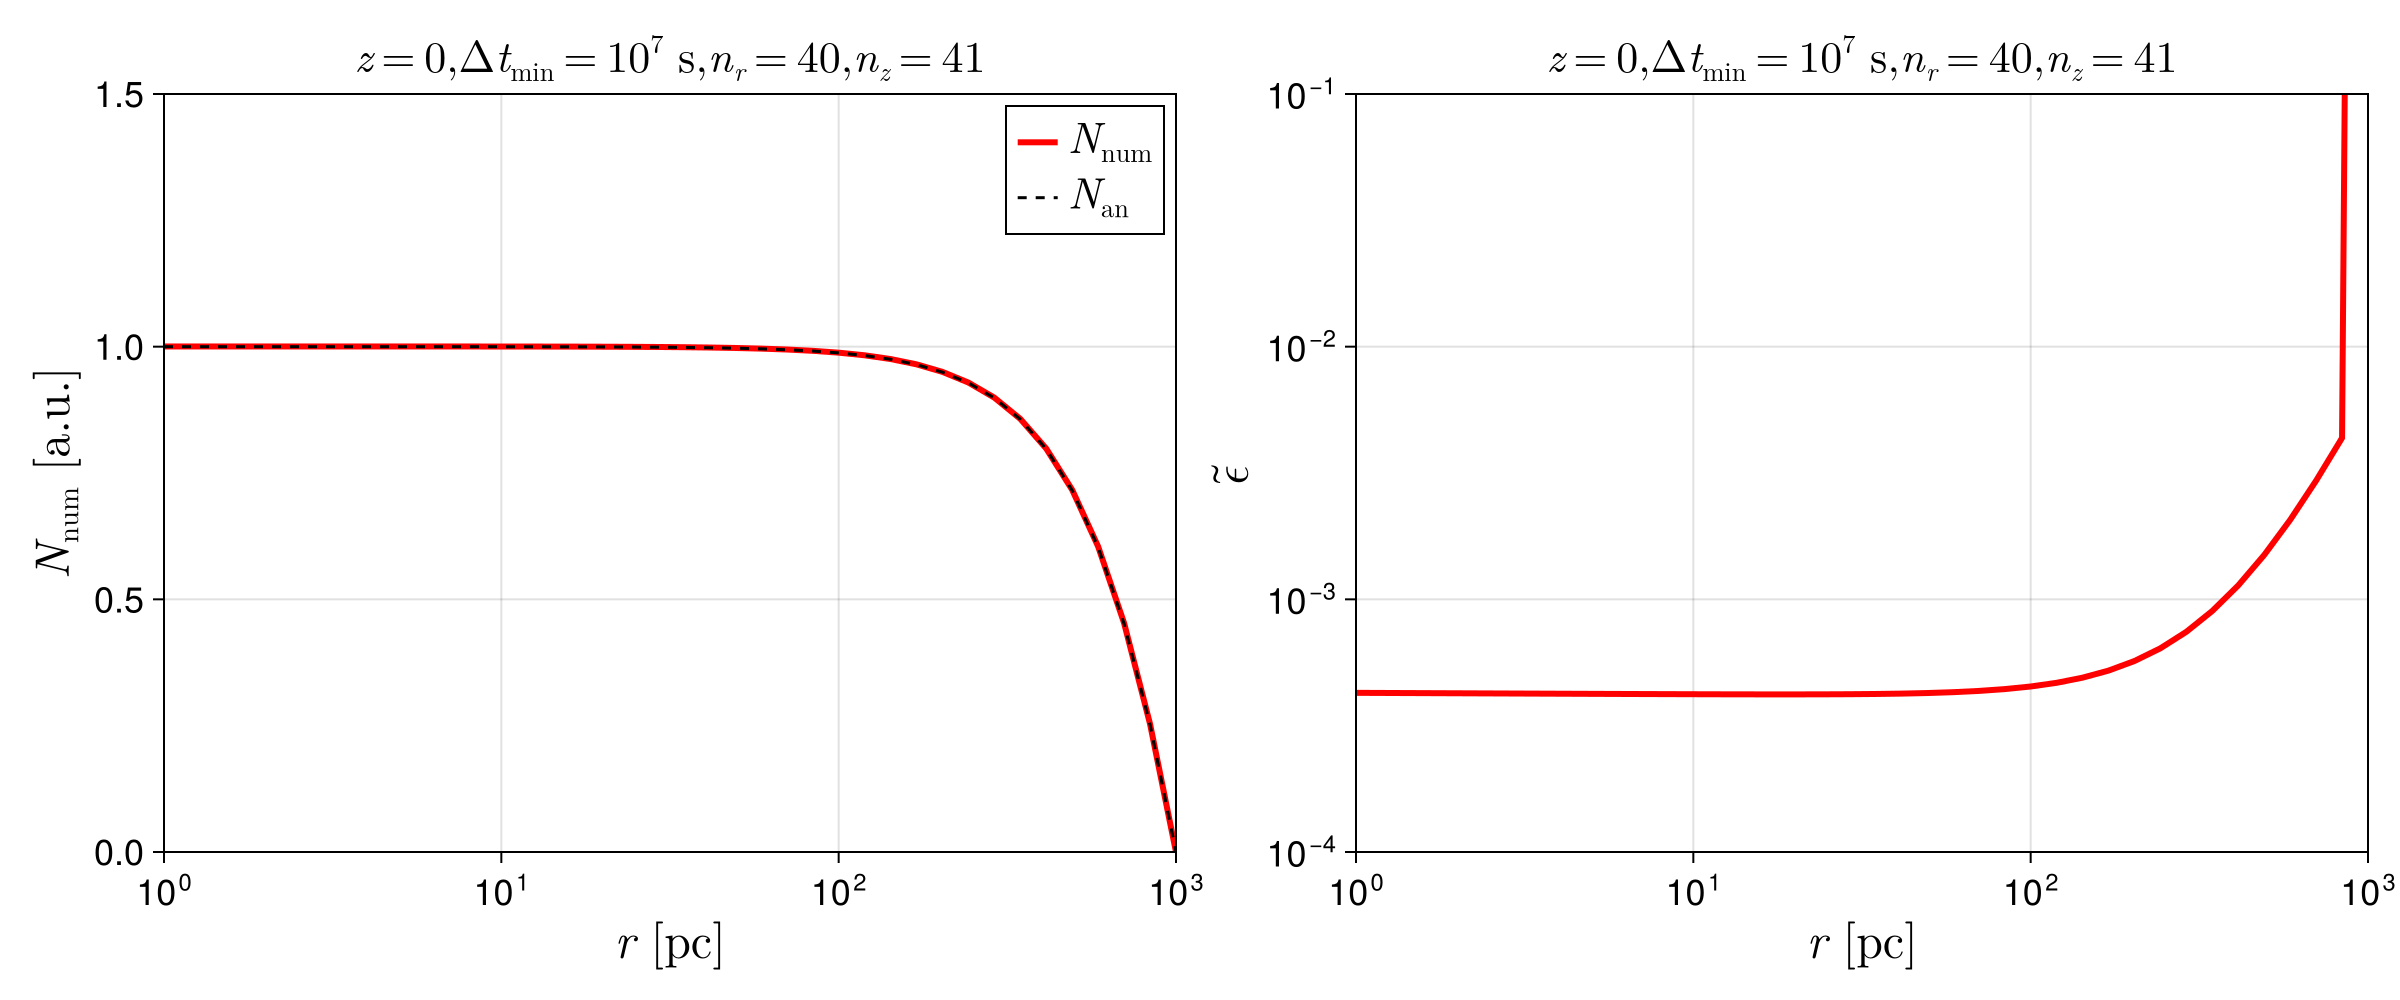

In [10]:
using CairoMakie

r = r_list ./ pc

fig = Figure(size = (1200, 500), fontsize=22)

# ---------------- LEFT: SOLUTION ----------------
ax1 = Axis(fig[1, 1],
    xlabel = L"r~[\mathrm{pc}]",
    ylabel = L"N_{\mathrm{num}}~[\mathrm{a.u.}]",
    title = L"z=0, \Delta t_{\mathrm{min}}=10^7~\mathrm{s}, n_r=40, n_z=41",
    xscale = log10,
    limits = ((1, 1e3), (0, 1.5)),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax1, r, prev_sol[:, 21, 10], color = :red, linewidth = 3,label = L"N_{\mathrm{num}}") # numerical (solid)
lines!(ax1, r, N_sol_diff[:, 21], color = :black, linestyle = :dash, label = L"N_{\mathrm{an}}") # analytical (dashed)
axislegend(ax1, fontsize = 18)

# ---------------- RIGHT: ERROR ----------------
err1 = abs.(N_sol_diff[:, 21] .- prev_sol[:, 21, 10]) ./ N_sol_diff[:, 21]

ax2 = Axis(fig[1, 2],
    xlabel = L"r~[\mathrm{pc}]",
    ylabel = L"\tilde{\epsilon}",
    title = L"z=0, \Delta t_{\mathrm{min}}=10^7~\mathrm{s}, n_r=40, n_z=41",
    xscale = log10,
    yscale = log10,
    limits = ((1, 1e3), (1e-4, 1e-1)),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax2, r, err1, color = :red, linewidth = 3)

fig